<a href="https://colab.research.google.com/github/zainabali12212/Smart-Medicine-OCR-Project/blob/main/Stage2-Bilingual-Analysis/Stage2_Bilingual_Structural_Tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Stage 2: Bilingual Support & Structural Analysis Tuning

**This notebook evaluates the system's ability to process Arabic-English labels and analyzes how different text layouts (Parallel vs. Linear) affect OCR extraction and structural accuracy.**

## 🛠 Environment Setup
This section installs the necessary **Arabic language pack** for Tesseract and imports the required libraries for image processing and bilingual OCR extraction.

In [1]:
# 1. Install Tesseract OCR + Arabic Language Pack
!apt-get install -y tesseract-ocr tesseract-ocr-ara
!pip install pytesseract

# 2. Import necessary libraries
import cv2
import pytesseract
import matplotlib.pyplot as plt
from google.colab import files
from PIL import Image

print("Environment Ready: Arabic OCR engine and libraries installed.")

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
The following NEW packages will be installed:
  tesseract-ocr-ara
0 upgraded, 1 newly installed, 0 to remove and 2 not upgraded.
Need to get 645 kB of archives.
After this operation, 1,447 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tesseract-ocr-ara all 1:4.00~git30-7274cfa-1.1 [645 kB]
Fetched 645 kB in 1s (923 kB/s)
Selecting previously unselected package tesseract-ocr-ara.
(Reading database ... 117540 files and directories currently installed.)
Preparing to unpack .../tesseract-ocr-ara_1%3a4.00~git30-7274cfa-1.1_all.deb ...
Unpacking tesseract-ocr-ara (1:4.00~git30-7274cfa-1.1) ...
Setting up tesseract-ocr-ara (1:4.00~git30-7274cfa-1.1) ...
Environment Ready: Arabic OCR engine and libraries installed.


---

## 🧪 Tested Scenarios (Cases)

### **Case 1: Parallel Bilingual Columns (Structural Interleaving)**
* **Challenge:** The label contains parallel English and Arabic columns. This structure often confuses the OCR engine's reading order.
* **Observation:** This test examines how `PSM 3` (Automatic Segmentation) handles side-by-side text and whether it causes line interleaving (mixing English and Arabic lines).

#### **Step 1: Image Upload**
Upload the medicine label that contains **parallel bilingual columns** to test structural interleaving.

In [2]:
print("Upload image for CASE 1 (Parallel Bilingual Columns):")
uploaded = files.upload()
file_name = list(uploaded.keys())[0]
image = cv2.imread(file_name)

Upload image for CASE 1 (Parallel Bilingual Columns):


Saving Image-digitising-pharmacy--bilingual-medication-information-on-pharmacy-dispensing-labels.png to Image-digitising-pharmacy--bilingual-medication-information-on-pharmacy-dispensing-labels.png


#### **Step 2: Adaptive Scaling & Grayscale**
Resizing the image to improve Arabic character clarity and removing color complexity.

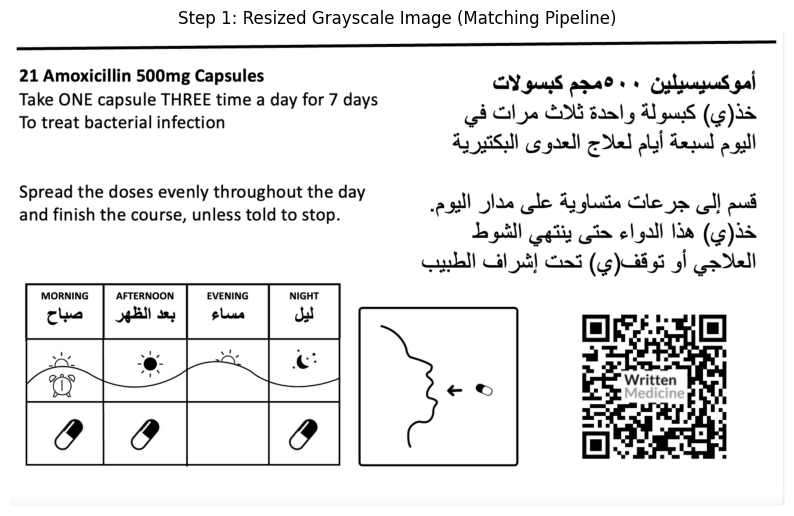

In [3]:
# Step 1: Adaptive Resizing & Grayscale Conversion
# 1. Resize first (matching Cell 4 logic)
img_resized = cv2.resize(image, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)

# 2. Convert the resized image to Grayscale
gray_image = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)

# Display the result
plt.figure(figsize=(10,10))
plt.imshow(gray_image, cmap='gray')
plt.title("Step 1: Resized Grayscale Image (Matching Pipeline)")
plt.axis('off')
plt.show()

#### **Step 3: Advanced Denoising & Binarization**
Preparing the final clean black-and-white input for the OCR engine.

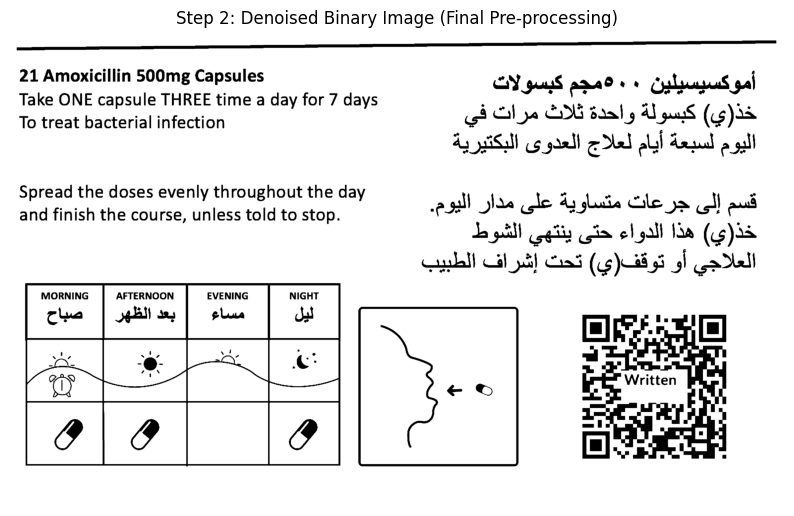

In [4]:
# Step 2: Denoising & Optimal Binarization
# 1. Denoising (Matching Cell 4 logic to remove sensor noise)
denoised_image = cv2.fastNlMeansDenoisingColored(img_resized, None, 10, 10, 7, 21)

# 2. Convert to Gray then apply Otsu's Thresholding
gray_step = cv2.cvtColor(denoised_image, cv2.COLOR_BGR2GRAY)
ret, thresh_image = cv2.threshold(gray_step, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Display the result
plt.figure(figsize=(10,10))
plt.imshow(thresh_image, cmap='gray')
plt.title("Step 2: Denoised Binary Image (Final Pre-processing)")
plt.axis('off')
plt.show()

#### **Step 4: Bilingual OCR Extraction (ara+eng)**
Executing the OCR with Arabic/English support and `PSM 3` to evaluate how the system handles the bilingual layout.

In [5]:
# 1. Image Scaling (Resizing to 2x)
img_resized = cv2.resize(image, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)

# 2. Denoising (Removing small dots/noise)
distorted = cv2.fastNlMeansDenoisingColored(img_resized, None, 10, 10, 7, 21)

# 3. Binarization (Converting to pure Black & White)
gray = cv2.cvtColor(distorted, cv2.COLOR_BGR2GRAY)
final_processed = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]

# Convert OpenCV array to PIL Image object for Tesseract compatibility
pil_image = Image.fromarray(final_processed)

# 4. Final OCR Extraction (Multi-language + PSM 3)
custom_config = r'-l ara+eng --psm 3'
raw_text = pytesseract.image_to_string(pil_image, config=custom_config).strip()

# Traffic Light Logic: Measures text quality based on noise ratio
def generate_traffic_report(text):
    clean_text = "".join(text.split())
    # Count non-alphanumeric characters as noise
    noise_count = sum(1 for char in clean_text if not char.isalnum())

    if len(clean_text) == 0:
        return "🔴 RED: OCR Failed (No text found)"
    elif noise_count > (len(clean_text) * 0.2): # 20% threshold for strict accuracy
        return "🟡 YELLOW: Low Accuracy (Text is noisy or unclear)"
    else:
        return "🟢 GREEN: Success (Clear text extracted)"

status_message = generate_traffic_report(raw_text)

# 6. Output the Result
print("="*40)
print(f"REPORT STATUS: {status_message}")
print("="*40)
print("EXTRACTED CONTENT:")
print(raw_text if raw_text else "[No Text Detected]")
print("="*40)

REPORT STATUS: 🟢 GREEN: Success (Clear text extracted)
EXTRACTED CONTENT:
21 Amoxicillin 500mg Capsules

أ كسبيسبلين وه 6 مجم كيسيو لات
‎eal on 3‏ حدة ثلاث م 1 أت ة ‎Take ONE capsule THREE time a day for 7 days‏
‎To treat bacterial infection Se 4 40 bal 9 ma ae‏

ظ اس : 4 ‎Spread the doses evenly throughout the day‏
‎ews‏ إلى جرعات متساوية على مدار اليوم. ‎and finish the course, unless told to stop.‏
خذ(ي) هذا الدواء حتى ينتهي الشوط
العلاجي أو توقف(ي) تحت إشراف الطبيب


---

### **Case 2: Linear Bilingual Layout & Unsupported Script Handling**
* **Challenge:** Testing a label where Arabic and English text are arranged **linearly** (one below the other) and contains an additional unsupported script (Hindi).
* **Objective:** 1. Confirm that linear layouts prevent line interleaving.
    2. Observe how the engine behaves when encountering scripts not included in the configuration (`ara+eng`).
* **Expected Result:** High accuracy for Arabic/English and phonetic approximations for the Hindi text.

#### **Step 1: Image Upload (Linear Layout)**
Upload the medicine label that has a **linear vertical structure** (English followed by Arabic) and contains unsupported scripts (e.g., Hindi).

In [6]:
print("Upload image for CASE 2 (Linear Layout):")
uploaded = files.upload()
file_name = list(uploaded.keys())[0]
image = cv2.imread(file_name)

Upload image for CASE 2 (Linear Layout):


Saving banner-img.png to banner-img.png


#### **Step 2: Adaptive Scaling & Grayscale**
Applying the same scaling parameters to ensure character consistency for the linear layout.

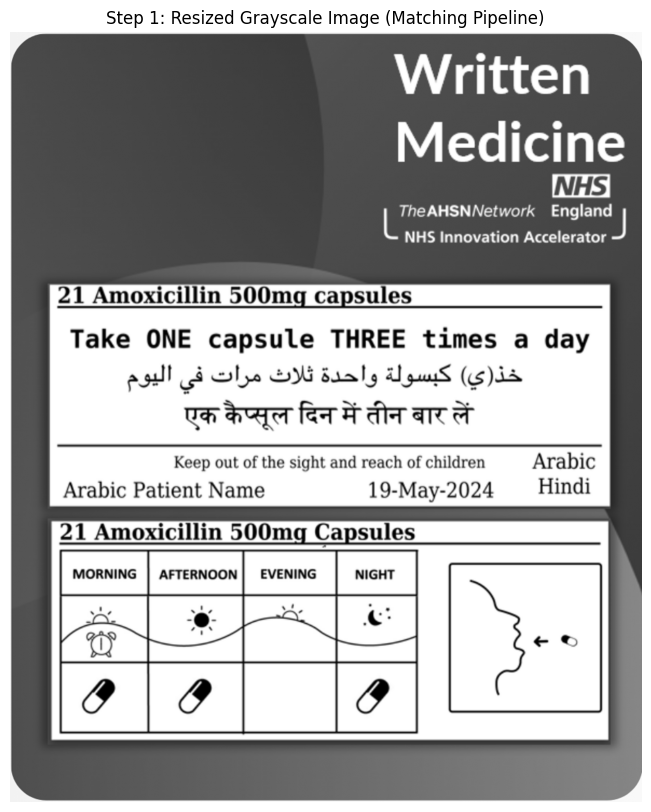

In [7]:
# Step 1: Adaptive Resizing & Grayscale Conversion
# 1. Resize first (matching Cell 4 logic)
img_resized = cv2.resize(image, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)

# 2. Convert the resized image to Grayscale
gray_image = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)

# Display the result
plt.figure(figsize=(10,10))
plt.imshow(gray_image, cmap='gray')
plt.title("Step 1: Resized Grayscale Image (Matching Pipeline)")
plt.axis('off')
plt.show()

#### **Step 3: Advanced Denoising & Binarization**
Generating the final binary mask to eliminate background noise and enhance the Hindi/Arabic scripts.

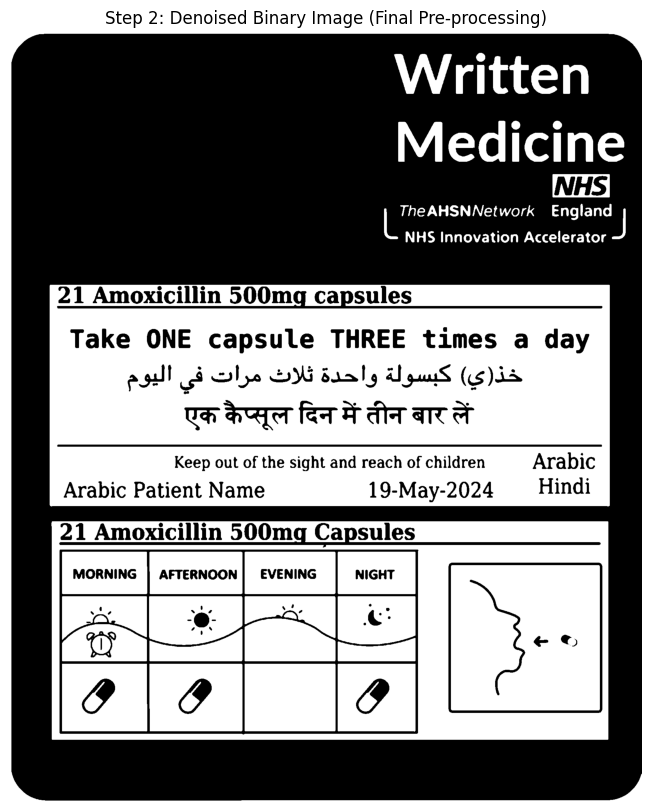

In [8]:
# Step 2: Denoising & Optimal Binarization
# 1. Denoising (Matching Cell 4 logic to remove sensor noise)
denoised_image = cv2.fastNlMeansDenoisingColored(img_resized, None, 10, 10, 7, 21)

# 2. Convert to Gray then apply Otsu's Thresholding
gray_step = cv2.cvtColor(denoised_image, cv2.COLOR_BGR2GRAY)
ret, thresh_image = cv2.threshold(gray_step, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Display the result
plt.figure(figsize=(10,10))
plt.imshow(thresh_image, cmap='gray')
plt.title("Step 2: Denoised Binary Image (Final Pre-processing)")
plt.axis('off')
plt.show()

#### **Step 4: Final Bilingual Extraction & Script Observation**
Extracting text using `ara+eng`. This step evaluates the success of the linear layout and observes how the engine handles the unsupported Hindi characters.

In [9]:
# 1. Image Scaling (Resizing to 2x)
img_resized = cv2.resize(image, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)

# 2. Denoising (Removing small dots/noise)
distorted = cv2.fastNlMeansDenoisingColored(img_resized, None, 10, 10, 7, 21)

# 3. Binarization (Converting to pure Black & White)
gray = cv2.cvtColor(distorted, cv2.COLOR_BGR2GRAY)
final_processed = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]

# Convert OpenCV array to PIL Image object for Tesseract compatibility
pil_image = Image.fromarray(final_processed)

# 4. Final OCR Extraction (Multi-language + PSM 3)
custom_config = r'-l ara+eng --psm 3'
raw_text = pytesseract.image_to_string(pil_image, config=custom_config).strip()

# Traffic Light Logic: Measures text quality based on noise ratio
def generate_traffic_report(text):
    clean_text = "".join(text.split())
    # Count non-alphanumeric characters as noise
    noise_count = sum(1 for char in clean_text if not char.isalnum())

    if len(clean_text) == 0:
        return "🔴 RED: OCR Failed (No text found)"
    elif noise_count > (len(clean_text) * 0.2): # 20% threshold for strict accuracy
        return "🟡 YELLOW: Low Accuracy (Text is noisy or unclear)"
    else:
        return "🟢 GREEN: Success (Clear text extracted)"

status_message = generate_traffic_report(raw_text)

# 6. Output the Result
print("="*40)
print(f"REPORT STATUS: {status_message}")
print("="*40)
print("EXTRACTED CONTENT:")
print(raw_text if raw_text else "[No Text Detected]")
print("="*40)

REPORT STATUS: 🟢 GREEN: Success (Clear text extracted)
EXTRACTED CONTENT:
Written

Medicine
NHS)

| ‏اللا‎
‎NHS Innovation Accelerator

21 Amoxicillin 500mg capsules

Take ONE capsule THREE times a day
‏خذري) كبسولة واحدة ثلاث مرات في اليوم‎
UE ager fer a dt at 8

Keep out of the sight and reach of children Arabic
Arabic Patient Name 19-May-2024 _— Hindi

21 Amoxicillin 500mg Capsules

ac men] ce [ we
a

O19} |9
